In [2]:
# Блок 1: Завантаження та Очищення Даних (Data Cleaning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування красивого стилю для графіків
sns.set_theme(style="whitegrid")

# Завантажуємо датасет Census Income
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status", 
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", 
    "hours-per-week", "native-country", "income"
]

# skipinitialspace=True прибирає зайві пробіли перед текстом, na_values="?" розпізнає пропуски
df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values="?")

print("к-ть пропусків до очищення:\n", df.isna().sum()[df.isna().sum() > 0])

# --- Data Cleaning ---
# Пропуски є у текстових колонках: workclass, occupation, native-country.
# Оскільки це категоріальні дані, найлогічніше заповнити їх найчастішим значенням (модою).
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Перевірка
print("\nпісля очищення датасет має розмір:", df.shape)
print("пропуски?", df.isna().any().any())

df.head()

к-ть пропусків до очищення:
 workclass         1836
occupation        1843
native-country     583
dtype: int64

після очищення датасет має розмір: (32561, 15)
пропуски? False


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


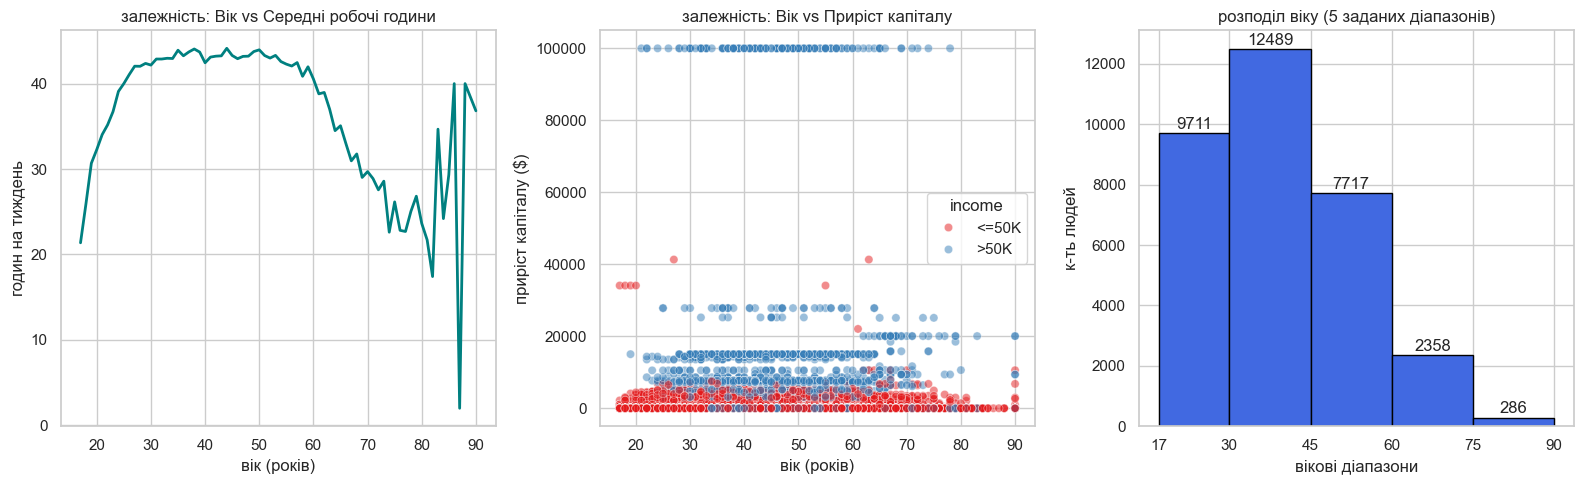

In [3]:
# Блок 2: Базові графіки (Integer vs Integer та Гістограма)

plt.figure(figsize=(16, 5))

# 1. Lineplot (Усереднена кількість робочих годин залежно від віку)
plt.subplot(1, 3, 1)
# Групуємо дані за віком, щоб лінія була чіткою і показувала тренд
age_hours = df.groupby('age')['hours-per-week'].mean().reset_index()
sns.lineplot(data=age_hours, x='age', y='hours-per-week', color='teal', linewidth=2)
plt.title("залежність: Вік vs Середні робочі години")
plt.xlabel("вік (років)")
plt.ylabel("годин на тиждень")

# 2. Scatter plot (Вік vs Приріст капіталу з поділом за доходом)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='age', y='capital-gain', hue='income', palette='Set1', alpha=0.5)
plt.title("залежність: Вік vs Приріст капіталу")
plt.xlabel("вік (років)")
plt.ylabel("приріст капіталу ($)")

# 3. Гістограма з 5 користувацькими діапазонами для віку
plt.subplot(1, 3, 3)
# Задаємо рівно 6 меж, щоб отримати 5 діапазонів: 17-30, 30-45, 45-60, 60-75, 75-90
custom_bins = [17, 30, 45, 60, 75, 90]
counts, edges, bars = plt.hist(df['age'], bins=custom_bins, color='royalblue', edgecolor='black')
plt.title("розподіл віку (5 заданих діапазонів)")
plt.xlabel("вікові діапазони")
plt.ylabel("к-ть людей")
plt.xticks(custom_bins) 

# Додаємо цифри кількості над стовпцями
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             int(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

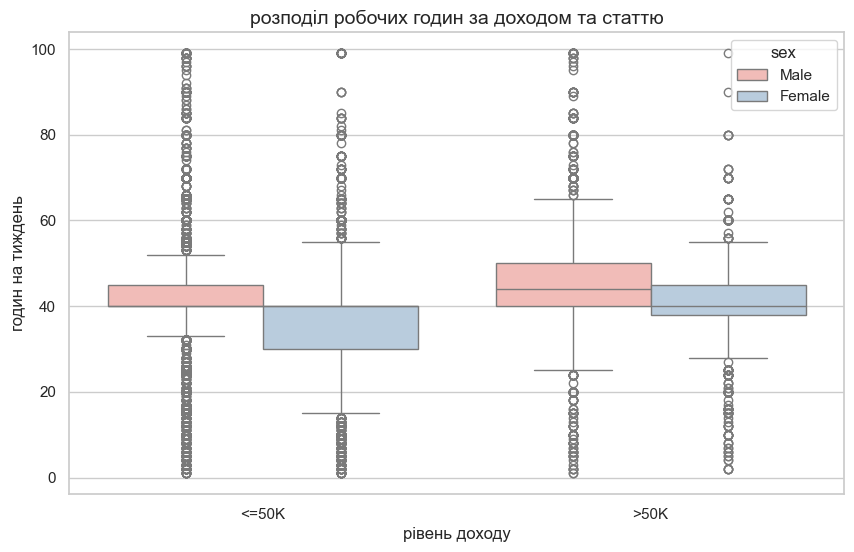

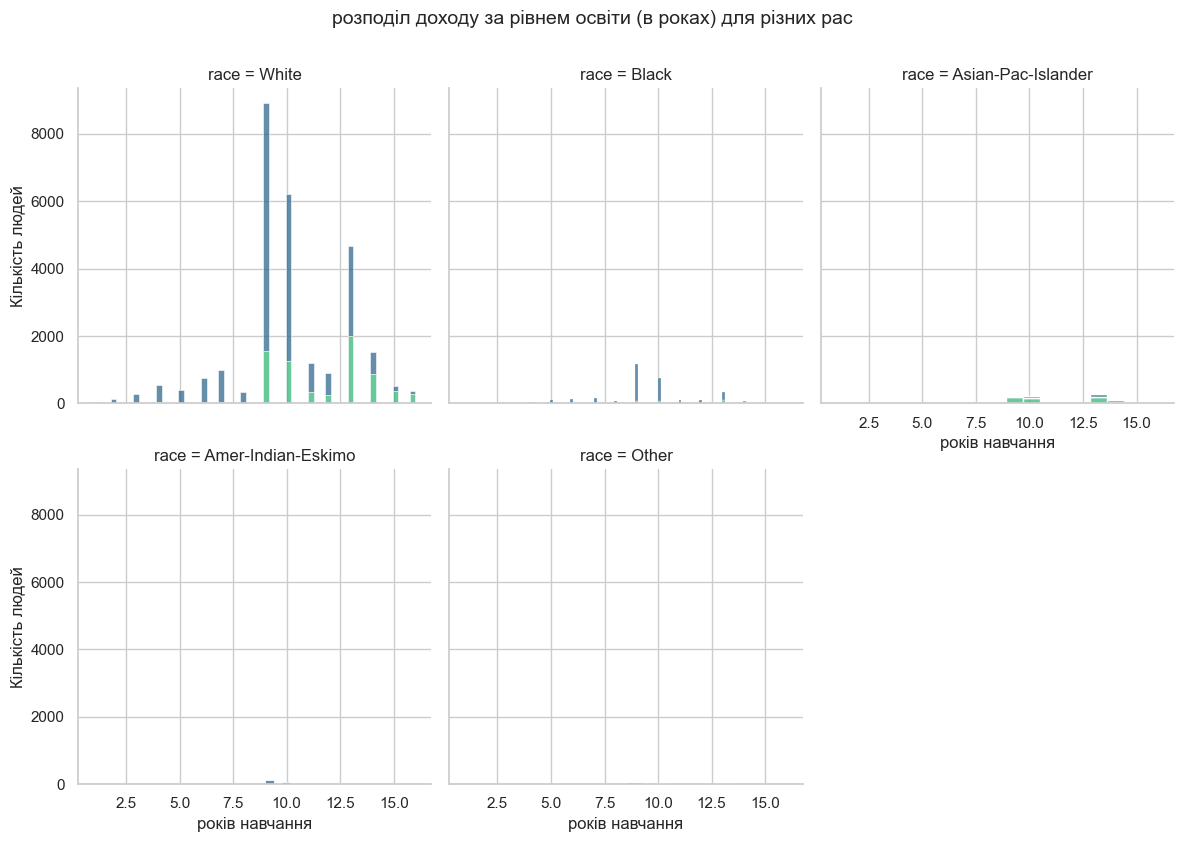

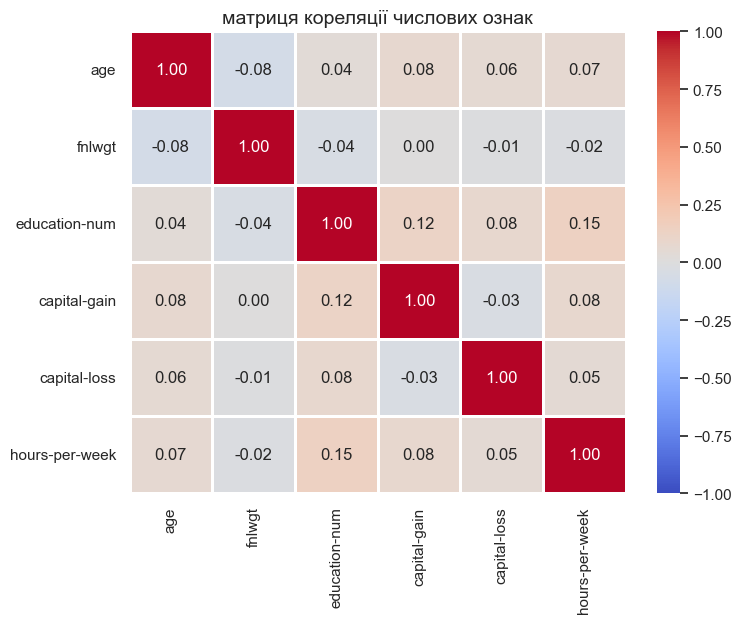

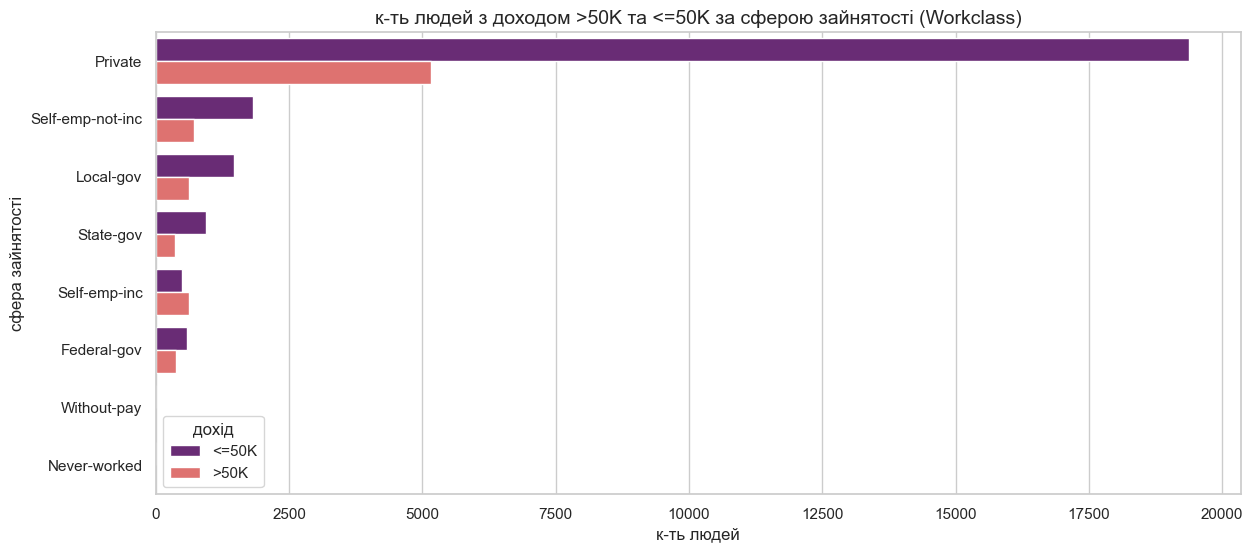

In [4]:
# Блок 3: Багатовимірна візуалізація та корисні інсайти

# 4. Boxplot (Ящик з вусами): Вплив статі та доходу на робочі години
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='income', y='hours-per-week', hue='sex', palette='Pastel1')
plt.title("розподіл робочих годин за доходом та статтю", fontsize=14)
plt.xlabel("рівень доходу")
plt.ylabel("годин на тиждень")
plt.show()

# 5. FacetGrid (Сітка графіків): Вплив освіти на дохід у різних расах
g = sns.FacetGrid(df, col="race", col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x="education-num", hue="income", multiple="stack", palette="viridis")
g.fig.suptitle("розподіл доходу за рівнем освіти (в роках) для різних рас", y=1.05, fontsize=14)
g.set_axis_labels("років навчання", "Кількість людей")
plt.show()

# 6. Correlation Heatmap (Теплова карта кореляції числових атрибутів)
plt.figure(figsize=(8, 6))
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, vmin=-1, vmax=1)
plt.title("матриця кореляції числових ознак", fontsize=14)
plt.show()

# 7. Багатовимірний Countplot: Дохід в залежності від сфери зайнятості
plt.figure(figsize=(14, 6))
sns.countplot(data=df, y='workclass', hue='income', palette='magma', order=df['workclass'].value_counts().index)
plt.title("к-ть людей з доходом >50K та <=50K за сферою зайнятості (Workclass)", fontsize=14)
plt.xlabel("к-ть людей")
plt.ylabel("сфера зайнятості")
plt.legend(title='дохід')
plt.show()